# 1. Imports + Config

In [1]:
import os
import numpy as np
import librosa
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from tqdm import tqdm

In [2]:
ROOT_PATH = "/kaggle/input/datasets/artharking/torgod/TorgoD"  # change this

SR = 16000
N_MFCC = 20
FRAME_LEN = 0.025  # 25 ms
HOP_LEN = 0.010    # 10 ms

FIXED_LEN = 250  # time frames (important for CNN)

BATCH_SIZE = 32
EPOCHS = 20
LR = 1e-3

In [3]:
label_map = {
    "Low":  0,
    "Medium":1,
    "VeryLow":2
}
NUM_CLASSES = len(label_map)

In [4]:
import os
import numpy as np
import librosa
from tqdm import tqdm

SAVE_PATH = "/kaggle/working/mfcc_features"
os.makedirs(SAVE_PATH, exist_ok=True)

def save_mfcc_dataset(root_dir, split):
    split_path = os.path.join(root_dir, split)

    for severity in os.listdir(split_path):
        sev_path = os.path.join(split_path, severity)

        if not os.path.isdir(sev_path):
            continue

        save_sev_path = os.path.join(SAVE_PATH, split, severity)
        os.makedirs(save_sev_path, exist_ok=True)

        for file in tqdm(os.listdir(sev_path), desc=f"{split}-{severity}"):
            if not file.endswith(".wav"):
                continue

            file_path = os.path.join(sev_path, file)

            mfcc = extract_mfcc(file_path)

            save_file = os.path.join(save_sev_path, file.replace(".wav", ".npy"))
            np.save(save_file, mfcc)

In [5]:
def extract_mfcc(file_path):
    y, sr = librosa.load(file_path, sr=SR)

    mfcc = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=N_MFCC,
        n_fft=int(FRAME_LEN * sr),
        hop_length=int(HOP_LEN * sr)
    )

    # Fix length (pad or truncate)
    if mfcc.shape[1] < FIXED_LEN:
        pad_width = FIXED_LEN - mfcc.shape[1]
        mfcc = np.pad(mfcc, ((0,0),(0,pad_width)), mode='constant')
    else:
        mfcc = mfcc[:, :FIXED_LEN]

    return mfcc

In [6]:
save_mfcc_dataset(ROOT_PATH, "train")
save_mfcc_dataset(ROOT_PATH, "test")


test-Medium: 100%|██████████| 243/243 [00:03<00:00, 72.42it/s]


In [7]:
import torch
from torch.utils.data import Dataset

class MFCCDataset(Dataset):
    def __init__(self, root_dir):
        self.files = []
        self.labels = []

        for severity in os.listdir(root_dir):
            sev_path = os.path.join(root_dir, severity)

            if not os.path.isdir(sev_path):
                continue

            for file in os.listdir(sev_path):
                if file.endswith(".npy"):
                    self.files.append(os.path.join(sev_path, file))
                    self.labels.append(label_map[severity])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        mfcc = np.load(self.files[idx])

        mfcc = torch.tensor(mfcc, dtype=torch.float32).unsqueeze(0)
        label = torch.tensor(self.labels[idx], dtype=torch.long)

        return mfcc, label

In [8]:
train_dataset = MFCCDataset("/kaggle/working/mfcc_features/train")
test_dataset  = MFCCDataset("/kaggle/working/mfcc_features/test")

In [9]:
val_size = int(0.1 * len(train_dataset))
train_size = len(train_dataset) - val_size

train_ds, val_ds = random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

In [10]:
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),

            nn.Conv2d(16, 32, 4, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 5, padding=1),
            nn.ReLU(),

            nn.Conv2d(64, 128, 2),
            nn.ReLU(),
            nn.MaxPool2d((1, 2))
        )

        # Adaptive pooling → avoids manual dimension calc
        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 50))

        self.classifier = nn.Sequential(
            nn.Linear(128 * 1 * 50, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, NUM_CLASSES)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.adaptive_pool(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNNModel().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

In [12]:
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121
Note: you may need to restart the kernel to use updated packages.


In [13]:
import os
import shutil

best_val_acc = 0
save_path = "/tmp/best_model.pth"

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    for x, y in tqdm(train_loader):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    val_acc = correct / total
    print(f"Epoch {epoch+1}/{EPOCHS}: Loss={train_loss:.4f}, Val Acc={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), save_path, _use_new_zipfile_serialization=False)
        print(f"✅ Best model updated! Val Acc: {val_acc:.4f}")

# After training, copy to working directory
shutil.copy(save_path, "./best_model.pth")
print("✅ Model copied to working directory!")

100%|██████████| 72/72 [00:04<00:00, 17.26it/s]


Epoch 1/20: Loss=50.2900, Val Acc=0.8189
✅ Best model updated! Val Acc: 0.8189


100%|██████████| 72/72 [00:03<00:00, 23.82it/s]


Epoch 2/20: Loss=22.6830, Val Acc=0.8976
✅ Best model updated! Val Acc: 0.8976


100%|██████████| 72/72 [00:03<00:00, 23.65it/s]


...

Epoch 18/20: Loss=0.7534, Val Acc=0.9685


100%|██████████| 72/72 [00:03<00:00, 23.12it/s]


Epoch 19/20: Loss=0.3561, Val Acc=0.9803
✅ Best model updated! Val Acc: 0.9803


100%|██████████| 72/72 [00:03<00:00, 23.08it/s]

Epoch 20/20: Loss=0.1114, Val Acc=0.9685
✅ Model copied to working directory!


In [14]:
def predict(file_path, model_path="best_model.pth"):
    model = CNNModel()
    model.load_state_dict(torch.load(model_path))
    model.eval()

    mfcc = extract_mfcc(file_path)
    mfcc = torch.tensor(mfcc).unsqueeze(0).unsqueeze(0)

    with torch.no_grad():
        output = model(mfcc)
        pred = torch.argmax(output, dim=1).item()

    inv_map = {v:k for k,v in label_map.items()}
    return inv_map[pred]

In [15]:
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [16]:
model = CNNModel().to(device)
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

CNNModel(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(4, 4), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): Conv2d(64, 128, kernel_size=(2, 2), stride=(1, 1))
    (8): ReLU()
    (9): MaxPool2d(kernel_size=(1, 2), stride=(1, 2), padding=0, dilation=1, ceil_mode=False)
  )
  (adaptive_pool): AdaptiveAvgPool2d(output_size=(1, 50))
  (classifier): Sequential(
    (0): Linear(in_features=6400, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=3, bias=True)
  )
)

In [17]:
correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():
    for x, y in tqdm(test_loader):
        x, y = x.to(device), y.to(device)

        outputs = model(x)
        preds = torch.argmax(outputs, dim=1)

        correct += (preds == y).sum().item()
        total += y.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

test_acc = correct / total
print(f"✅ Test Accuracy: {test_acc:.4f}")

100%|██████████| 20/20 [00:00<00:00, 106.60it/s]

✅ Test Accuracy: 0.9906


In [18]:
from sklearn.metrics import confusion_matrix, classification_report

print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=label_map.keys()))


Classification Report:

              precision    recall  f1-score   support

         Low       0.98      1.00      0.99        53
      Medium       0.99      0.99      0.99       243
     VeryLow       0.99      0.99      0.99       344

    accuracy                           0.99       640
   macro avg       0.99      0.99      0.99       640
weighted avg       0.99      0.99      0.99       640



In [19]:
# import pandas as pd

# inv_map = {v: k for k, v in label_map.items()}

# filenames = [os.path.basename(test_dataset.files[i]) for i in range(len(test_dataset))]

# scores = []
# all_preds = []
# all_labels = []

# model.eval()
# with torch.no_grad():
#     for x, y in tqdm(DataLoader(test_dataset, batch_size=32, shuffle=False)):
#         x, y = x.to(device), y.to(device)
#         outputs = model(x)
#         probs = torch.softmax(outputs, dim=1)
#         best_scores = probs.max(dim=1).values
#         preds = torch.argmax(outputs, dim=1)

#         scores.extend(best_scores.cpu().numpy())
#         all_preds.extend(preds.cpu().numpy())
#         all_labels.extend(y.cpu().numpy())

# df = pd.DataFrame({
#     "filename":      filenames,
#     "score":         scores,
#     "predict class": [inv_map[p] for p in all_preds],
#     "actual class":  [inv_map[l] for l in all_labels],
# })

# df.to_excel("/kaggle/working/results.xlsx", index=False)
# print("✅ Saved results.xlsx")

import pandas as pd

inv_map = {v: k for k, v in label_map.items()}

# Class order: Normal → High → Mid → Low → Very_Low
class_order = [ "Low","Medium", "VeryLow"]

filenames  = [os.path.basename(test_dataset.files[i]) for i in range(len(test_dataset))]

all_preds      = []
all_labels     = []
all_raw_scores = []   # raw logits per class
all_softmax    = []   # softmax probabilities per class

model.eval()
with torch.no_grad():
    for x, y in tqdm(DataLoader(test_dataset, batch_size=32, shuffle=False)):
        x, y = x.to(device), y.to(device)
        outputs = model(x)                          # raw logits: (batch, NUM_CLASSES)
        probs   = torch.softmax(outputs, dim=1)     # softmax probabilities
        preds   = torch.argmax(outputs, dim=1)

        all_raw_scores.extend(outputs.cpu().numpy())
        all_softmax.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

# Build DataFrame
df = pd.DataFrame({"filename": filenames})

# Raw logit score for each class
for cls_name in class_order:
    df[f"score_{cls_name}"] = [row[label_map[cls_name]] for row in all_raw_scores]

# Softmax probability for each class
for cls_name in class_order:
    df[f"prob_{cls_name}"] = [row[label_map[cls_name]] for row in all_softmax]

# Final prediction & actual label
df["predict class"] = [inv_map[p] for p in all_preds]
df["actual class"]  = [inv_map[l] for l in all_labels]

# Save both CSV and Excel
df.to_csv("/kaggle/working/results.csv",   index=False)
df.to_excel("/kaggle/working/results.xlsx", index=False)
print("✅ Saved results.csv and results.xlsx")
print(df.head())


100%|██████████| 20/20 [00:00<00:00, 96.06it/s]


✅ Saved results.csv and results.xlsx
            filename  score_Low  score_Medium  score_VeryLow  prob_Low  \
0  M05-S1-L-0010.npy   9.895537     -4.407872     -12.578373  0.999999   
1  F01-S1-L-0013.npy   9.438920     -7.811614      -2.028052  0.999990   
2  M05-S1-L-0015.npy   6.421553      0.384664     -20.013411  0.997617   
3  M05-S1-L-0025.npy  10.121942     -4.992865     -12.812033  1.000000   
4  F01-S1-L-0016.npy   7.004094     -5.377162      -1.485542  0.999790   

    prob_Medium  prob_VeryLow predict class actual class  
0  6.139146e-07  1.736617e-10           Low          Low  
1  3.222432e-08  1.047015e-05           Low          Low  
2  2.383288e-03  3.299173e-12           Low          Low  
3  2.727235e-07  1.096228e-10           Low          Low  
4  4.195635e-06  2.055450e-04           Low          Low  


KeyError: 'Medium'

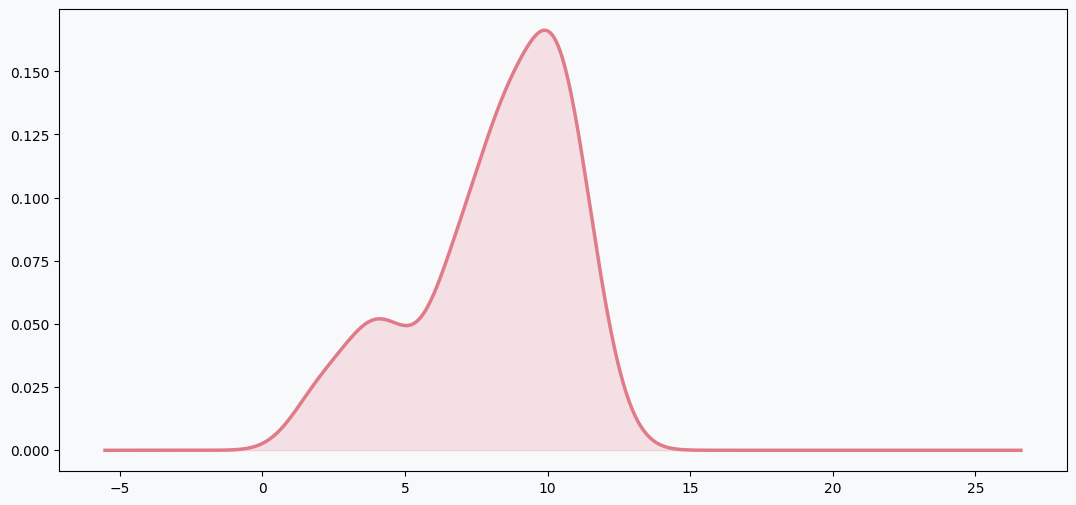

In [20]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

# Class order: Normal → High → Mid → Low → Very_Low
class_order = [ "Low","Medium", "VeryLow"]
colors = {
    "Normal":   "#7ba7d4",
    "High":     "#e8a87c",
    "Mid":      "#6bb89e",
    "Low":      "#e07b8a",
    "Very_Low": "#9b8ec4",
   
}

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor("#f8f9fb")
ax.set_facecolor("#f8f9fb")

# Compute x-axis range from real scores
all_scores_flat = []
for cls_name in class_order:
    col = f"score_{cls_name}"
    cls_rows = df[df["actual class"] == cls_name][col].values
    all_scores_flat.extend(cls_rows)

x_min = min(all_scores_flat) - 0.5
x_max = max(all_scores_flat) + 0.5
x = np.linspace(x_min, x_max, 600)

# Plot each class using REAL scores from df
for cls_name in class_order:
    col = f"score_{cls_name}"
    cls_scores = df[df["actual class"] == cls_name][col].values
    if len(cls_scores) < 2:
        continue
    kde = gaussian_kde(cls_scores, bw_method=0.35)
    y_vals = kde(x)
    ax.plot(x, y_vals, color=colors[cls_name], linewidth=2.5, label=cls_name, zorder=3)
    ax.fill_between(x, y_vals, alpha=0.20, color=colors[cls_name], zorder=2)

# # Decision boundary at logit = 0
# ax.axvline(0, color="#555", linewidth=1.3, linestyle="--", alpha=0.6, zorder=4)
# ax.text(0.05, ax.get_ylim()[1] * 0.95, "Decision\nBoundary",
        # fontsize=8, color="#444",
        # bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#aaa", alpha=0.8))

ax.set_xlabel("Raw Logit Score  (q)", fontsize=12, labelpad=8)
ax.set_ylabel("Density  p(q)", fontsize=12, labelpad=8)
ax.set_title("Class Score Distributions — MFCC-CNN (Real Scores)",
             fontsize=14, fontweight="bold", pad=12)
ax.legend(title="Risk Class", fontsize=10, title_fontsize=10,
          framealpha=0.9, edgecolor="#ccc")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#ccc")
plt.tight_layout()
plt.savefig("/kaggle/working/distribution_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved distribution_plot.png")


for single file usage 

In [ ]:
# def predict(file_path, model, device):
#     model.eval()

#     mfcc = extract_mfcc(file_path)
#     mfcc = torch.tensor(mfcc, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

#     with torch.no_grad():
#         output = model(mfcc)
#         pred = torch.argmax(output, dim=1).item()

#     inv_map = {v:k for k,v in label_map.items()}
#     return inv_map[pred]

# file = "/kaggle/input/YOUR_DATASET/test/Low/sample.wav"

# print("Prediction:", predict(file, model, device))